In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
from velovi import preprocess_data, VELOVI

import seaborn as sns
import matplotlib.pyplot as plt

/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'n

In [2]:
# !python -m pip install scvi-colab
# from scvi_colab import install
# install()

In [3]:
data_outdir = 'processed_data/'
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [4]:
model_outdir = 'modeling_results/'

## Apply VeloVI

In [5]:
adata_rna = preprocess_data(adata_rna)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [6]:
VELOVI.setup_anndata(adata_rna , spliced_layer="Ms", unspliced_layer="Mu")
vae = VELOVI(adata_rna )
vae.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 310/500:  62%|██████▏   | 310/500 [17:03:05<10:27:03, 198.02s/it, v_num=1, train_loss_step=-983, train_loss_epoch=-1.05e+3]    
Monitored metric elbo_validation did not improve in the last 45 records. Best score: -1043.690. Signaling Trainer to stop.


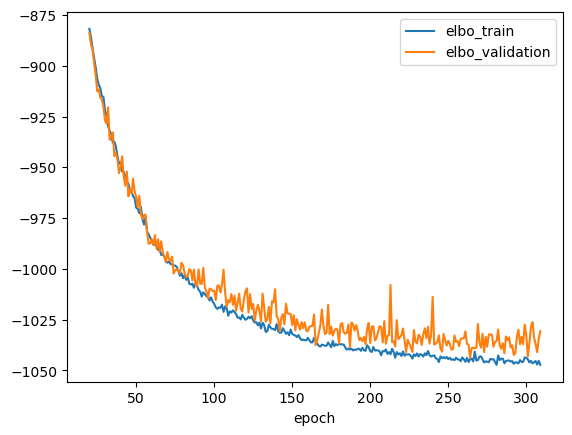

In [7]:
fig, ax = plt.subplots()
vae.history["elbo_train"].iloc[20:].plot(ax=ax, label="train")
vae.history["elbo_validation"].iloc[20:].plot(ax=ax, label="validation")
plt.legend()

In [12]:
import pickle
f = open(model_outdir+'vae.p', 'wb')
pickle.dump(vae, f)
f.close()

In [5]:
import pickle
f = open(model_outdir+'vae.p', 'rb')
vae = pickle.load(f)
f.close()

In [13]:
def add_velovi_outputs_to_adata(adata, vae):
    latent_time = vae.get_latent_time(n_samples=25)
    velocities = vae.get_velocity(n_samples=25, velo_statistic="mean")

    t = latent_time
    scaling = 20 / t.max(0)

    adata.layers["velocity"] = velocities / scaling
    adata.layers["latent_time_velovi"] = latent_time

    adata.var["fit_alpha"] = vae.get_rates()["alpha"] / scaling
    adata.var["fit_beta"] = vae.get_rates()["beta"] / scaling
    adata.var["fit_gamma"] = vae.get_rates()["gamma"] / scaling
    adata.var["fit_t_"] = (
        torch.nn.functional.softplus(vae.module.switch_time_unconstr)
        .detach()
        .cpu()
        .numpy()
    ) * scaling
    print(scaling)
    adata.layers["fit_t"] = latent_time.values * scaling.values[np.newaxis, :]
    adata.var['fit_scaling'] = 1.0

add_velovi_outputs_to_adata(adata_rna, vae)

Gene
ABCA2      4.439031
ABCC3      2.294774
ABCC4      5.788400
ABHD2      2.718119
ABHD4      3.030826
             ...   
ZFPM1      2.984832
ZMYND8     2.692172
ZNF385D    3.076762
ZNF521     3.342217
ZYX        5.098940
Length: 605, dtype: float32


In [14]:
scv.tl.velocity_graph(adata_rna)

computing velocity graph (using 1/128 cores)


  0%|          | 0/10935 [00:00<?, ?cells/s]

    finished (0:00:51) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:03) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


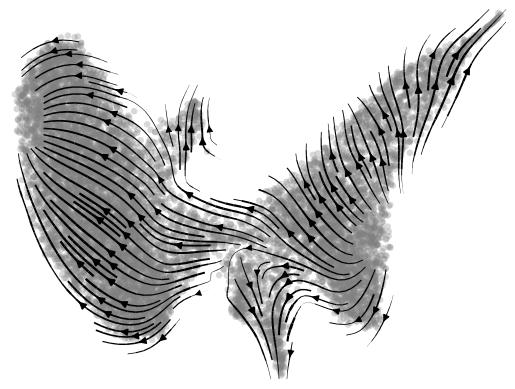

In [15]:
scv.pl.velocity_embedding_stream(adata_rna, basis='umap')

In [16]:
adata_rna.write(model_outdir+'VeloVI_result.h5ad')


In [5]:
vv_result = sc.read_h5ad(model_outdir+'VeloVI_result.h5ad')


In [7]:
import pickle
f = open(model_outdir+'vae.p', 'rb')
vae = pickle.load(f)
f.close()

In [8]:
s_fits, u_fits = vae.get_expression_fit(n_samples = 20)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [9]:
s_fits.to_csv(model_outdir+'VeloVI_s_fits.csv')
u_fits.to_csv(model_outdir+'VeloVI_u_fits.csv')